# Performance comparision

## We have implemented Logistics Regression, LDA, KNN and Naive Bayes. Lets compares their results

In [13]:
import sys
sys.path.append("../src")
from models.logistic.prediction import run_logistic_pipeline
from models.LDA.lda import run_lda_pipeline
from models.KNN.knn_model import run_knn_pipeline
from models.Naive.naive_bayes_model import run_naive_bayes_pipeline
import pandas as pd
from compare.compare_classifiers import compare_models
from sklearn.model_selection import train_test_split

In [14]:
# Same data and splitting for all models to ensure a fair comparison
df = pd.read_csv("../data/processed/heart_failure_clinical_records_dataset_processed.csv")

features = [
    "time",
    "age_centered",
    "ejection_fraction_centered",
    "sodium_creatinine_interaction",
]

X = df[features]
y = df["DEATH_EVENT"]
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [15]:
logit_results = run_logistic_pipeline(X_train, X_test, y_train, y_test)
lda_results = run_lda_pipeline(X_train, X_test, y_train, y_test)
knn_results = run_knn_pipeline(X_train, X_test, y_train, y_test)
nb_results = run_naive_bayes_pipeline(X_train, X_test, y_train, y_test)

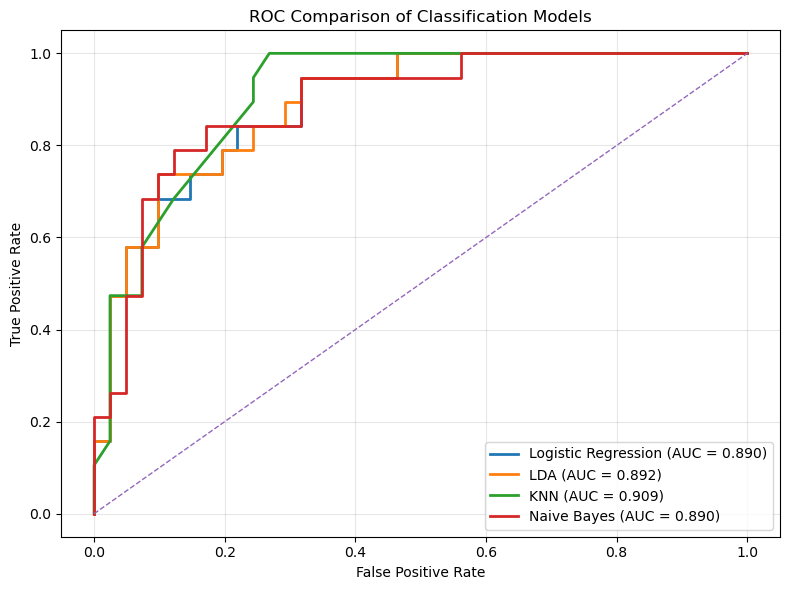

,Model,Accuracy,Precision,Recall,F1,AUC,best_k
0,KNN,0.7833,0.7500,0.4737,0.5806,0.9089,19.0
1,LDA,0.8333,0.8462,0.5789,0.6875,0.8922,NaN
2,Logistic Regression,0.8167,0.7857,0.5789,0.6667,0.8896,NaN
3,Naive Bayes,0.8500,0.8125,0.6842,0.7429,0.8896,NaN


In [16]:
comparison_df = compare_models(
    [
        logit_results,
        lda_results,
        knn_results,
        nb_results,
    ],
    title="ROC Comparison of Classification Models",
    sort_by="auc",
    ascending=False,
)

comparison_df